In [1]:
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path(r"C:\Users\skous\Super-League-odds-research")
SCOTLAND_RESEARCH = REPO_ROOT / "scotland_research"

assert SCOTLAND_RESEARCH.exists(), SCOTLAND_RESEARCH
sys.path.insert(0, str(SCOTLAND_RESEARCH))


from data.load_model_dataset import load_dataset
from evaluation.report import write_evaluation_outputs
from evaluation.walk_forward import run_walk_forward

from models import models_for_individual_feature_removal_test

In [2]:
MODEL_DATASET = (REPO_ROOT/"data"/"processed"/"scotland"/"scotland_model_dataset.csv")
OUTPUT_DIR = (REPO_ROOT/"artifacts"/"scotland_player_feature_removal")

MODEL_DATASET, OUTPUT_DIR

(WindowsPath('C:/Users/skous/Super-League-odds-research/data/processed/scotland/scotland_model_dataset.csv'),
 WindowsPath('C:/Users/skous/Super-League-odds-research/artifacts/scotland_player_feature_removal'))

In [3]:
def difference_from_full_model(
    #Comparison with the full player model

    metrics: pd.DataFrame,
    group_column: str | None = None) -> pd.DataFrame:
    compared = metrics.copy()
    full_rows = compared[compared["model"].eq(FULL_PLAYER_MODEL_NAME)]

    if group_column is None:
        if len(full_rows) != 1:
            raise ValueError("Expected exactly one overall full-player-model row")
        compared["full_model_log_loss"] = full_rows["log_loss"].iloc[0]

    else:
        full_by_group = full_rows.set_index(group_column)["log_loss"]
        if full_by_group.index.duplicated().any():
            raise ValueError(f"Multiple full-player-model rows for {group_column}")
        compared["full_model_log_loss"] = compared[group_column].map(full_by_group)

        if compared["full_model_log_loss"].isna().any():
            raise ValueError(f"A {group_column} group has no full-player-model row")

    compared["log_loss_vs_full_player_model"] = (
        compared["log_loss"] - compared["full_model_log_loss"]
    )

    explanations = []
    for model, difference in zip(
        compared["model"],
        compared["log_loss_vs_full_player_model"],
        strict=True,
    ):
        if model == "closing_market":
            explanations.append("closing market reference")
        elif model == FULL_PLAYER_MODEL_NAME:
            explanations.append("full player model reference")
        elif difference > 0:
            explanations.append("removed group helped the full model")
        elif difference < 0:
            explanations.append("removed group hurt the full model")
        else:
            explanations.append("removed group made no difference")

    compared["result"] = explanations
    return compared

In [4]:
# Load data
dataset = load_dataset(MODEL_DATASET)
dataset.shape

(1121, 46)

In [5]:
models = models_for_individual_feature_removal_test()
print(len(models))

28


In [6]:
# Run walk forward
result = run_walk_forward(dataset, models_for_individual_feature_removal_test())
result.overall_metrics

,model,out_of_sample_matches,log_loss,brier_score,accuracy,closing_market_log_loss,log_loss_vs_closing_market,log_loss_relative_to_closing_market,market_comparison
0,closing_market,665,0.917761,0.538017,0.568421,0.917761,0.000000,0.000000,baseline
1,market_plus_player_form_without_recent_minutes...,665,0.932632,0.544551,0.565414,0.917761,0.014871,0.016204,within_2_percent
2,market_plus_player_form_without_starters_witho...,665,0.932640,0.544380,0.571429,0.917761,0.014879,0.016212,within_2_percent
3,market_plus_player_form_without_rating_mean_5,665,0.932692,0.544290,0.575940,0.917761,0.014931,0.016269,within_2_percent
4,market_plus_player_form_without_starters_witho...,665,0.933132,0.544384,0.574436,0.917761,0.015371,0.016748,within_2_percent
5,market_plus_player_form_without_npxg_per90_sum_5,665,0.936659,0.547231,0.562406,0.917761,0.018898,0.020591,worse_by_more_than_2_percent
6,market_plus_player_form_without_defensive_acti...,665,0.936939,0.546680,0.562406,0.917761,0.019178,0.020897,worse_by_more_than_2_percent
7,market_plus_player_form_without_key_passes_per...,665,0.937584,0.547358,0.568421,0.917761,0.019823,0.021599,worse_by_more_than_2_percent
8,market_plus_player_form_without_shots_per90_sum_5,665,0.937816,0.547258,0.557895,0.917761,0.020055,0.021852,worse_by_more_than_2_percent
9,market_plus_player_form_all_features,665,0.937831,0.547318,0.559398,0.917761,0.020070,0.021868,worse_by_more_than_2_percent


In [8]:
import matplotlib.pyplot as plt

from constants import PLAYER_FEATURES

families = {
    "player_form": "Player Form",
    "market_plus_player_form": "Market + Player Form",
    "dixon_coles_player_form": "Dixon–Coles + Player Form",
}

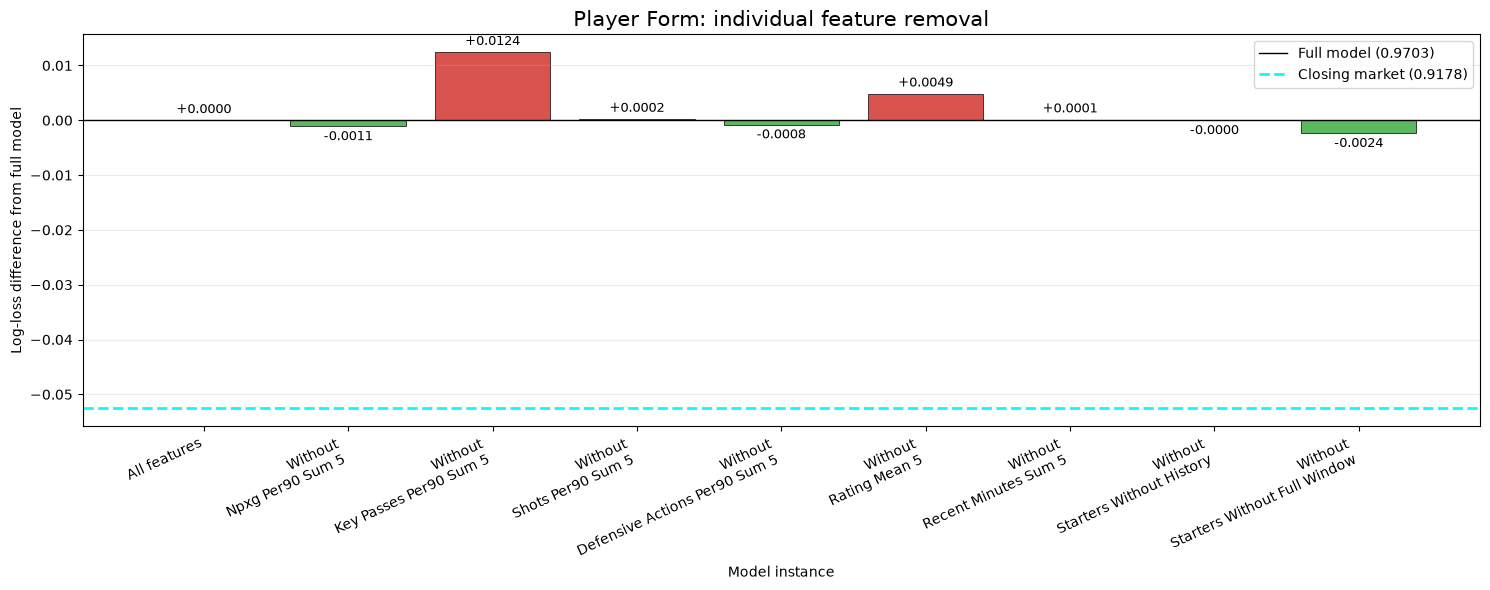

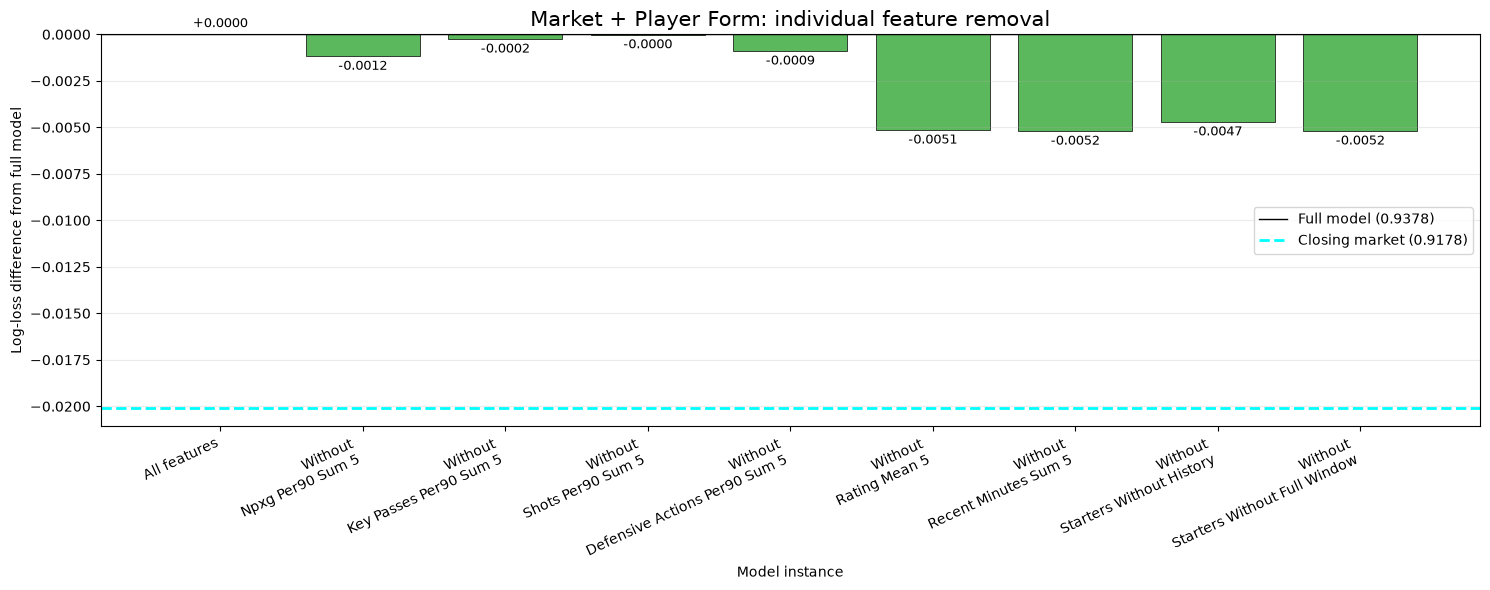

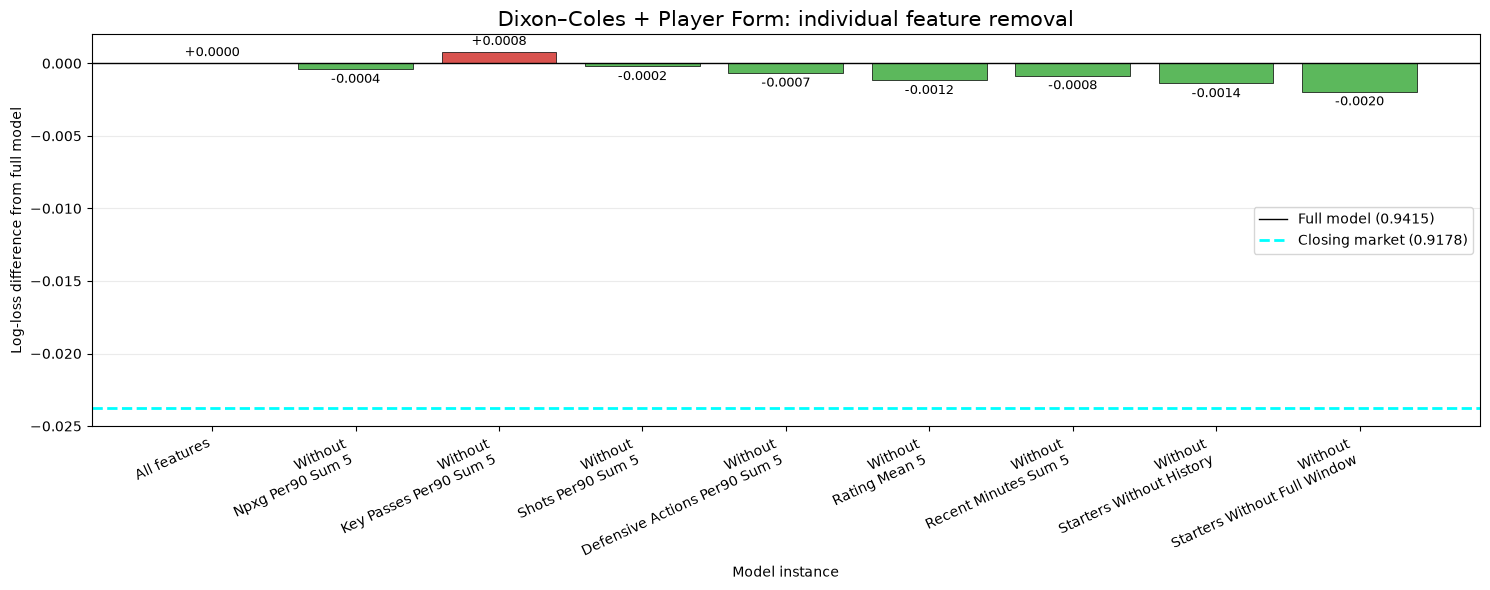

In [15]:
plt.style.use("default")
metrics = result.overall_metrics.set_index("model")
closing_market_loss = metrics.loc["closing_market", "log_loss"]

feature_labels = {feature: feature.removeprefix("diff_").replace("_", " ").title() for feature in PLAYER_FEATURES}

for family_name, chart_title in families.items():
    full_model_name = f"{family_name}_all_features"

    removal_model_names = [f"{family_name}_without_{feature.removeprefix('diff_')}" for feature in PLAYER_FEATURES]

    model_names = [full_model_name, *removal_model_names]

    missing_models = [name for name in model_names if name not in metrics.index]

    if missing_models:
        raise ValueError(f"Missing results for {chart_title}: {missing_models}")

    log_losses = metrics.loc[model_names, "log_loss"]
    full_model_loss = log_losses.loc[full_model_name]

    # Positive means removing the feature made the model worse.
    differences = log_losses - full_model_loss

    labels = ["All features"] + [f"Without\n{feature_labels[feature]}" for feature in PLAYER_FEATURES]

    colors = [
        "#4472C4" if model == full_model_name
        else "#D9534F" if difference > 0
        else "#5CB85C"
        for model, difference in zip(model_names, differences,strict=True)
    ]

    fig, ax = plt.subplots(figsize=(15, 6))

    bars = ax.bar(labels, differences, color=colors, edgecolor="black", linewidth=0.5)

    ax.axhline(0, color="black", linewidth=1, label=f"Full model ({full_model_loss:.4f})")

    market_difference = closing_market_loss - full_model_loss
    ax.axhline(market_difference, color="cyan", linestyle="--", linewidth=2, label=f"Closing market ({closing_market_loss:.4f})")

    ax.bar_label(bars, labels=[f"{value:+.4f}" for value in differences], padding=3, fontsize=9)

    ax.set_title(f"{chart_title}: individual feature removal", fontsize=15)
    ax.set_ylabel("Log-loss difference from full model")
    ax.set_xlabel("Model instance")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    output_path = Path("../visuals/out") / "feature_removal_contribution.png"
    fig.savefig(output_path, dpi=600, bbox_inches="tight")

    plt.show()

# Current state thoughts

For all model families, witholding specific parts of the data reduces the model's difference from the market's opinion, with the Market + Player form witnessing a substantial improvement, being the only model family coming within 2% of closing market odds. This slight improvement in probability induction still shows that none of the currently selected models are able to beat our set market baseline.